<a href="https://colab.research.google.com/github/melia1702/Pertemuan-kelima/blob/main/Tugas_MG_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Silahkan upload gambar...


Saving WhatsApp Image 2023-08-20 at 08.19.19.jpeg to WhatsApp Image 2023-08-20 at 08.19.19.jpeg
Ukuran citra: (1600, 1200)

=== HASIL EVALUASI FILTER ===
Filter		MSE		PSNR		SSIM
Mean 3x3        153.56	 26.27	 0.4698
Mean 5x5        71.47	 29.59	 0.6891
Gaussian Sigma1 120.34	 27.33	 0.5390
Gaussian Sigma2 74.44	 29.41	 0.6797
Median 3x3      0.69	 49.76	 0.9979
Median 5x5      1.50	 46.38	 0.9954
Min Filter      6099.02	 10.28	 0.2377


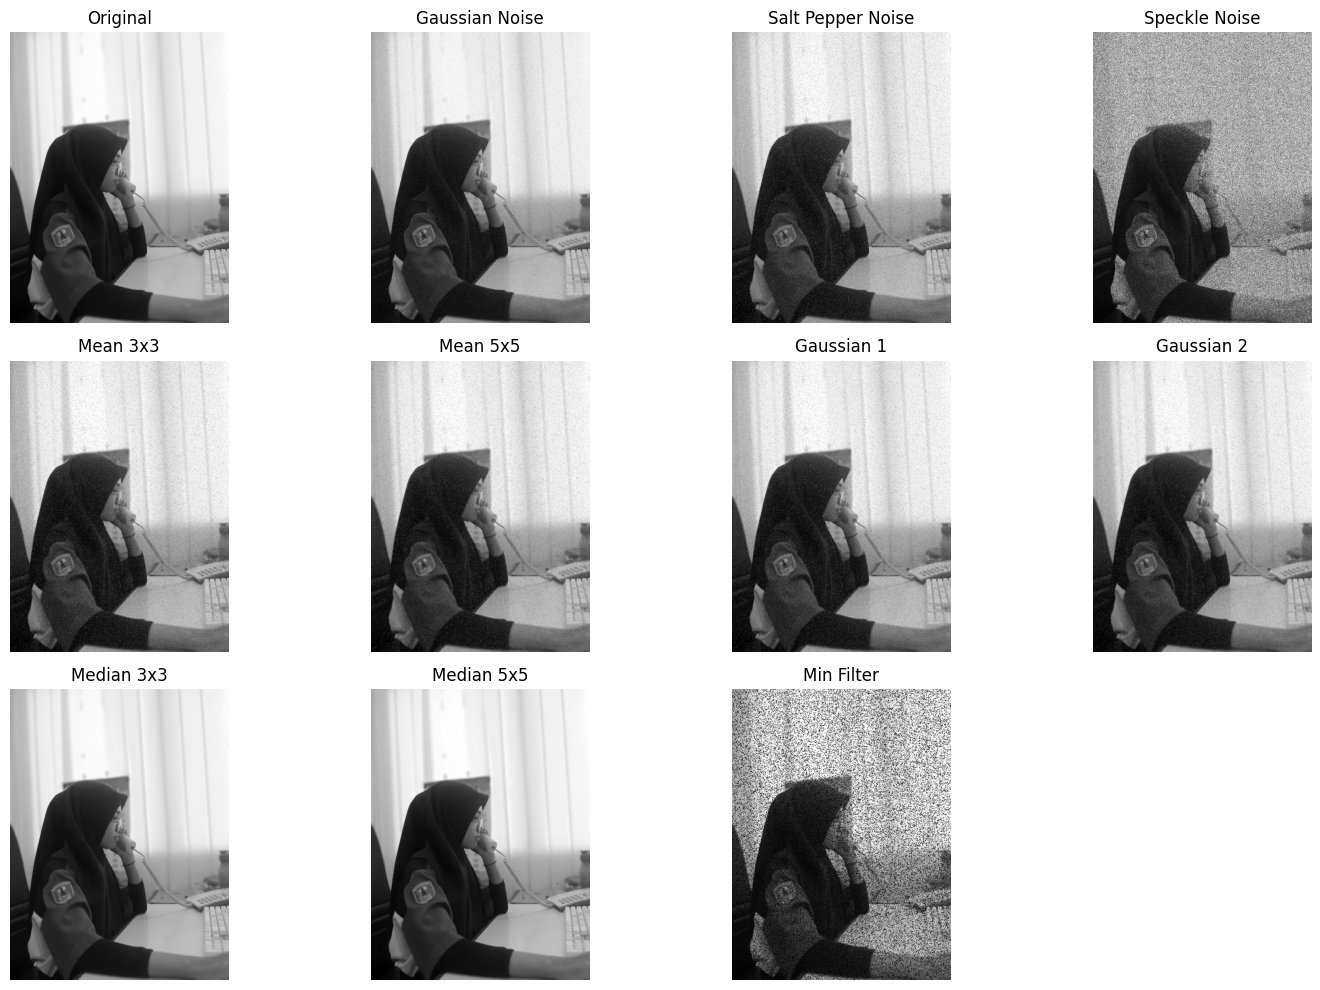

In [6]:
# ============================================
# Evaluasi Spatial Filtering untuk Restorasi Citra
# ============================================

import cv2
import numpy as np
import time
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from google.colab import files

# ============================================
# 1. Upload Image
# ============================================

print("Silahkan upload gambar...")
uploaded = files.upload()

# ambil nama file
filename = list(uploaded.keys())[0]

# baca gambar
img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError("Gambar tidak berhasil dibaca!")

print("Ukuran citra:", img.shape)

# ============================================
# 2. Membuat Noise
# ============================================

# Gaussian Noise
gaussian_noise = img + np.random.normal(0,20,img.shape)
gaussian_noise = np.clip(gaussian_noise,0,255).astype(np.uint8)

# Salt Pepper Noise
sp_noise = img.copy()
prob = 0.05
rand = np.random.random(img.shape)

sp_noise[rand < prob/2] = 0
sp_noise[rand > 1-prob/2] = 255

# Speckle Noise
speckle_noise = img + img * np.random.randn(*img.shape)
speckle_noise = np.clip(speckle_noise,0,255).astype(np.uint8)

# ============================================
# 3. Filter Linear
# ============================================

mean3 = cv2.blur(sp_noise,(3,3))
mean5 = cv2.blur(sp_noise,(5,5))

gauss1 = cv2.GaussianBlur(sp_noise,(5,5),1)
gauss2 = cv2.GaussianBlur(sp_noise,(5,5),2)

# ============================================
# 4. Filter Non Linear
# ============================================

median3 = cv2.medianBlur(sp_noise,3)
median5 = cv2.medianBlur(sp_noise,5)

kernel = np.ones((3,3),np.uint8)
min_filter = cv2.erode(sp_noise,kernel)

# ============================================
# 5. Fungsi Evaluasi
# ============================================

def mse(a,b):
    return np.mean((a.astype("float") - b.astype("float"))**2)

def psnr(a,b):
    m = mse(a,b)
    if m == 0:
        return float('inf')
    return 10*np.log10(255**2/m)

def compute_ssim(a,b):
    return ssim(a,b)

# ============================================
# 6. Evaluasi Filter
# ============================================

filters = {
    "Mean 3x3": mean3,
    "Mean 5x5": mean5,
    "Gaussian Sigma1": gauss1,
    "Gaussian Sigma2": gauss2,
    "Median 3x3": median3,
    "Median 5x5": median5,
    "Min Filter": min_filter
}

print("\n=== HASIL EVALUASI FILTER ===")
print("Filter\t\tMSE\t\tPSNR\t\tSSIM")

for name, filtered in filters.items():

    m = mse(img, filtered)
    p = psnr(img, filtered)
    s = compute_ssim(img, filtered)

    print(f"{name:15} {m:.2f}\t {p:.2f}\t {s:.4f}")

# ============================================
# 7. Visualisasi
# ============================================

plt.figure(figsize=(15,10))

images = [
    ("Original", img),
    ("Gaussian Noise", gaussian_noise),
    ("Salt Pepper Noise", sp_noise),
    ("Speckle Noise", speckle_noise),
    ("Mean 3x3", mean3),
    ("Mean 5x5", mean5),
    ("Gaussian 1", gauss1),
    ("Gaussian 2", gauss2),
    ("Median 3x3", median3),
    ("Median 5x5", median5),
    ("Min Filter", min_filter)
]

for i,(title,image) in enumerate(images):

    plt.subplot(3,4,i+1)
    plt.imshow(image,cmap='gray')
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.show()